# Data Visualization: Histograms, Box Plots and Scatter Plots

Covers core data visualization techniques including histograms, box plots, and scatter plots. Topics include distributions, identify outliers.

## 1. Visualization & Intuition: Seeing Data Before Computing

Data visualization is a foundational step in understanding any dataset. Before calculating summary statistics or fitting complex models, visualizations reveal distributions and relationships, including patterns and outliers that guide subsequent analysis and help prevent analytical mistakes.

## 2. Introduction

The human visual system excels at pattern recognition, making visualization one of the most powerful tools in the data scientist's arsenal. A well-crafted histogram can instantly reveal whether data follows a normal distribution or exhibits skewness. A scatter plot can expose non-linear relationships that correlation coefficients might obscure. Box plots highlight outliers that could derail a regression model if left unaddressed.

Exploratory data analysis through visualization has been championed by statisticians like John Tukey, who emphasized the importance of "looking at the data" before applying formal statistical procedures. This philosophy recognizes that computational tools are most effective when guided by human intuition and domain knowledge, both of which are enhanced through visual exploration.

This notebook introduces three basic visualization techniques (histograms, box plots, and scatter plots) that form the basis of exploratory data analysis. These tools give complementary perspectives on data. By mastering these visualizations, practitioners develop intuition about their data that maps them from mechanical calculators into thoughtful analysts capable of asking the right questions and interpreting results in meaningful ways.

## 3. Histograms: Understanding Distribution

Histograms display the distribution of a continuous variable by dividing the range of values into bins and counting how many observations fall into each bin. The resulting bar chart provides an immediate visual sense of where data is concentrated, how spread out it is, and whether it exhibits unusual patterns like multiple peaks or long tails.


The shape of a histogram reveals important information about the underlying data generation process. A symmetric, bell-shaped distribution centered around a single peak suggests data that might follow a normal distribution, which justifies many classical statistical procedures. Skewed distributions, with long tails extending to the right or left, indicate that extreme values occur more frequently than a normal distribution would predict. Such skewness might suggest the need for data transformation or the use of robust statistical methods that don't assume normality.

Histograms also expose potential data quality issues. Unexpected gaps in the distribution might indicate missing categories or measurement problems. Sharp cutoffs at round numbers could reveal data entry practices rather than true properties of the measured phenomenon. Multiple distinct peaks (bimodal or multimodal distributions) often suggest that the data combines multiple subpopulations that should be analyzed separately.

The choice of bin width significantly affects histogram appearance and interpretation. Too few bins obscure detail and make the distribution appear overly smooth. Too many bins create a jagged appearance dominated by random noise rather than meaningful signal. Most visualization libraries provide reasonable default binning strategies, but practitioners should experiment with different bin widths to ensure they're not missing important features or being misled by arbitrary binning choices.

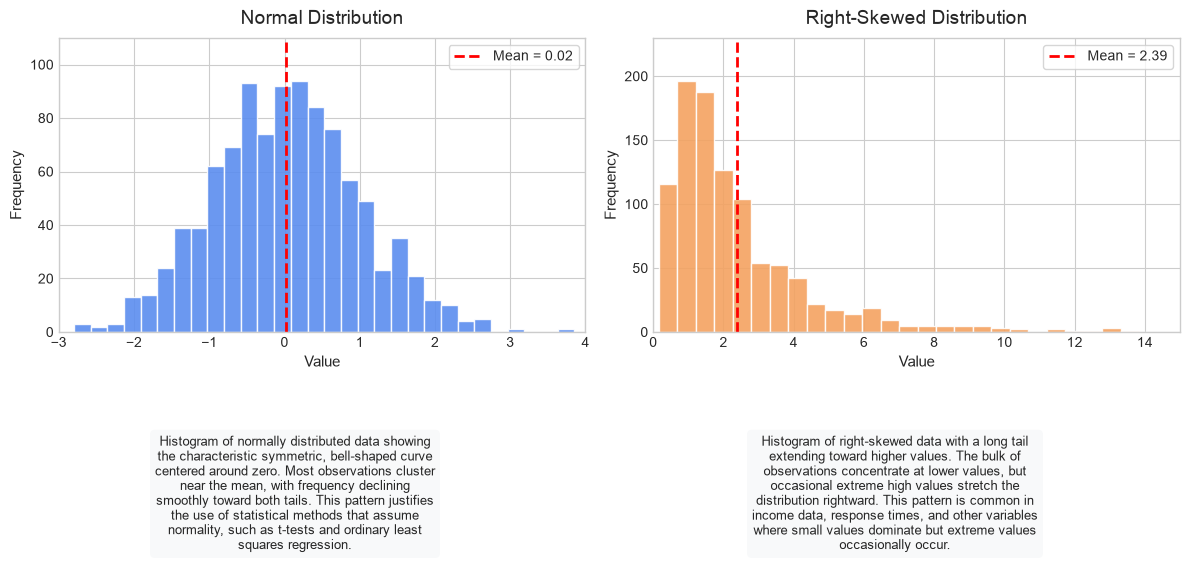

In [1]:
import numpy as np
import matplotlib.pyplot as plt



#Set Clean style
plt.style.use('seaborn-v0_8-whitegrid')

#Generate Sample data
np.random.seed(42)


#Normal distribution 
normal_data = np.random.normal(loc=0, scale=1, size=1000)

#Right Skewed Distribution
skewed_data = np.random.lognormal(mean=0.5, sigma=0.8, size=1000)

# Create figure with two subplots
fig, axes = plt.subplots(1,2,figsize=(12,5))


#Normal Distrubution
ax1 = axes[0]
n1, bins1, patches1 = ax1.hist(normal_data, bins=32, color='#5B8DEF',edgecolor='white',alpha=0.9)
mean_normal = np.mean(normal_data)
ax1.axvline(mean_normal, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_normal:.2f}')
ax1.set_title('Normal Distribution', fontsize=14, pad=10)
ax1.set_xlabel('Value', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.legend(loc='upper right', frameon=True)
ax1.set_xlim(-3, 4)
ax1.set_ylim(0, 110)

# Skweed Distribution
ax2 = axes[1]
n2,bins2, patches2 = ax2.hist(skewed_data,bins=40,color='#F4A261',edgecolor='white',alpha=0.9)
mean_skewed = np.mean(skewed_data)
ax2.axvline(mean_skewed, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_skewed:.2f}')
ax2.set_title('Right-Skewed Distribution', fontsize=14, pad=10)
ax2.set_xlabel('Value', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.legend(loc='upper right', frameon=True)
ax2.set_xlim(0, 15)
ax2.set_ylim(0, 230)


# Adjust layout and add descriptive text below
plt.tight_layout(rect=[0, 0.22, 1, 1])

# Add the descriptive captions
fig.text(0.25, 0.12,
         "Histogram of normally distributed data showing\n"
         "the characteristic symmetric, bell-shaped curve\n"
         "centered around zero. Most observations cluster\n"
         "near the mean, with frequency declining\n"
         "smoothly toward both tails. This pattern justifies\n"
         "the use of statistical methods that assume\n"
         "normality, such as t-tests and ordinary least\n"
         "squares regression.",
         ha='center', va='top', fontsize=9, wrap=True,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='none'))

fig.text(0.75, 0.12,
         "Histogram of right-skewed data with a long tail\n"
         "extending toward higher values. The bulk of\n"
         "observations concentrate at lower values, but\n"
         "occasional extreme high values stretch the\n"
         "distribution rightward. This pattern is common in\n"
         "income data, response times, and other variables\n"
         "where small values dominate but extreme values\n"
         "occasionally occur.",
         ha='center', va='top', fontsize=9, wrap=True,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa', edgecolor='none'))

plt.savefig("Plots/HistoGramPlot.png", dpi=150)
plt.show()

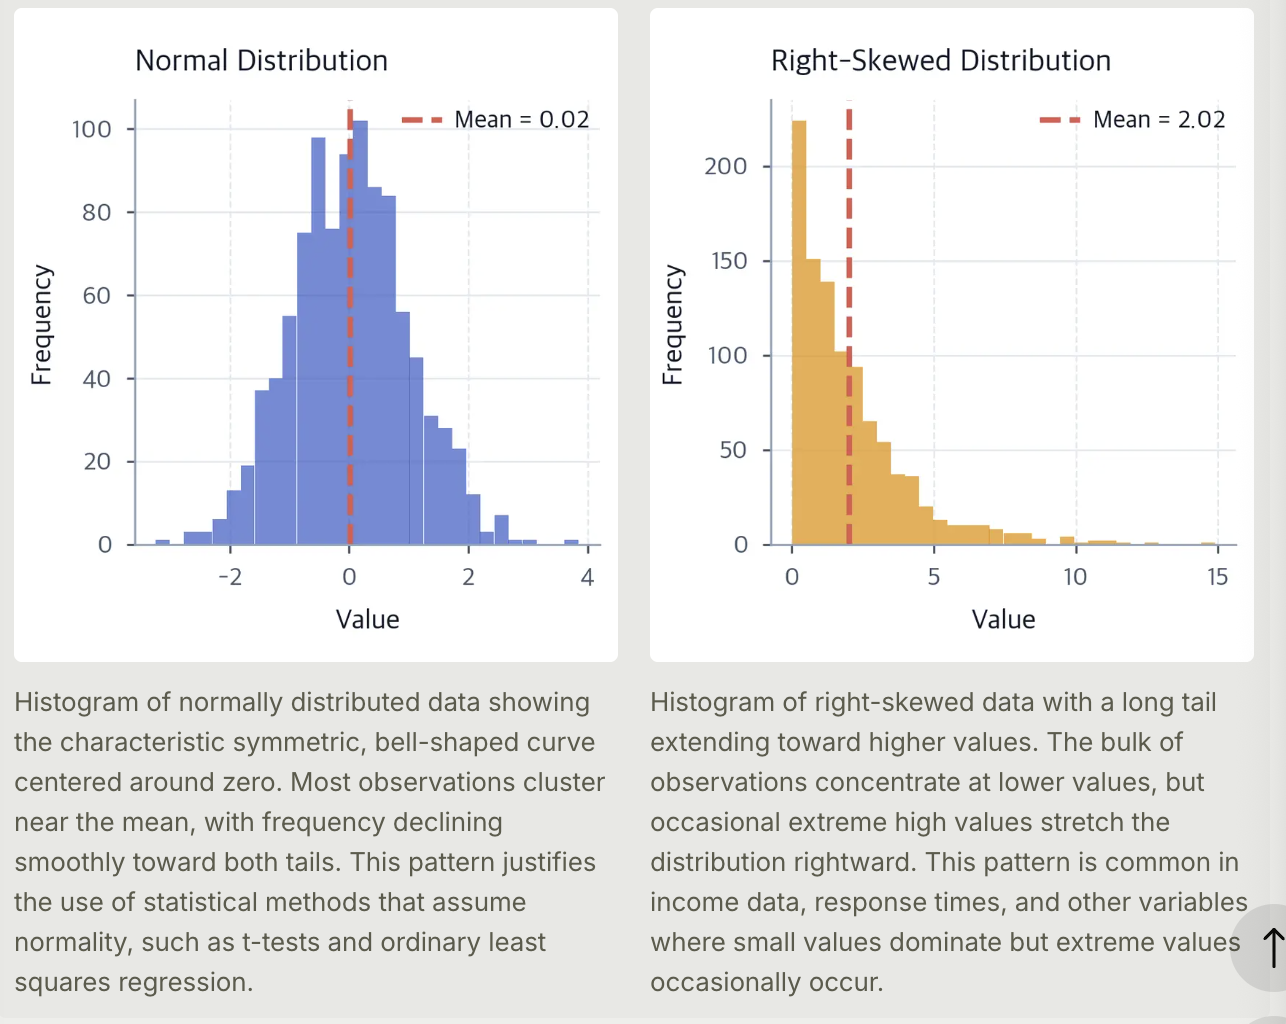

## 4. Box Plots: Summarizing Key Statistics

Box plots, also known as box-and-whisker plots, provide a concise visual summary of a distribution's key statistical properties. 
1. The rectangular box spans from the first quartile (25th percentile) to the third quartile (75th percentile), capturing the middle 50% of the data. 2. A line inside the box marks the **median**(50th percentile). 
3. **Whiskers** extend from the box to show the range of typical values, 
4. while individual points beyond the *whiskers flag potential outliers*.

This compact representation makes box plots particularly valuable for comparing distributions across multiple groups. Arranging several box plots side by side immediately reveals differences in central tendency (median positions), spread (box heights), and outlier patterns. Such comparisons might show that one group has systematically higher values than another, or that some groups exhibit more variability, or that outliers occur predominantly in certain categories.

The definition of outliers in box plots typically follows the interquartile range (IQR) rule: values more than 1.5 times the IQR below the first quartile or above the third quartile are flagged as potential outliers. While this rule is somewhat arbitrary, it provides a useful starting point for identifying observations that warrant closer inspection. Some outliers are valid extreme values that carry important information about rare events or boundary conditions. Others indicate measurement errors, data entry mistakes, or observations from a different population that should be excluded or modeled separately.

Box plots sacrifice some information that histograms preserve, particularly about the detailed shape of the distribution between quartiles. A bimodal distribution with two distinct peaks might appear as a simple box plot with a large interquartile range. This limitation means box plots work best as complements to, rather than replacements for, histograms, with each visualization type highlighting different aspects of the data.

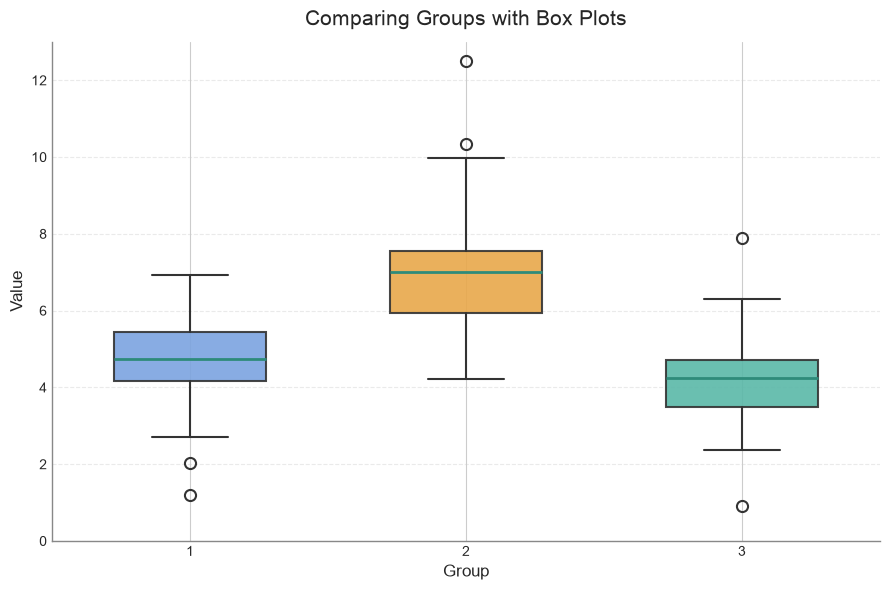

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data that closely matches the visual characteristics
# Group A: symmetric around ~5, moderate spread, one low outlier
group_a = np.random.normal(loc=4.9, scale=1.1, size=80)
group_a = np.clip(group_a, 2.0, 7.8)          # control whiskers
group_a = np.append(group_a, 1.2)             # low outlier

# Group B: higher center (~7), wider spread, one high outlier
group_b = np.random.normal(loc=6.9, scale=1.4, size=80)
group_b = np.clip(group_b, 3.3, 12.0)
group_b = np.append(group_b, 12.5)            # high outlier

# Group C: lowest values, most compact, two outliers
group_c = np.random.normal(loc=4.1, scale=0.85, size=80)
group_c = np.clip(group_c, 2.0, 6.3)
group_c = np.append(group_c, [0.9, 7.9])      # low + high outliers

data = [group_a, group_b, group_c]
labels = ['Group A', 'Group B', 'Group C']
colors = ['#7BA3E0', '#E8A84A', '#5AB8A8']   # matching the image colors

# Create the figure
fig, ax = plt.subplots(figsize=(9, 6))

# Draw box plots
bp = ax.boxplot(
    data,
    label=labels,
    patch_artist=True,
    widths=0.55,
    showfliers=True,
    medianprops=dict(color='#2E8B7A', linewidth=2),
    whiskerprops=dict(color='#333333', linewidth=1.5),
    capprops=dict(color='#333333', linewidth=1.5),
    flierprops=dict(
        marker='o',
        markerfacecolor='none',
        markeredgecolor='#333333',
        markersize=8,
        markeredgewidth=1.5
    ),
    boxprops=dict(linewidth=1.5, edgecolor='#333333')
)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.9)

# Styling
ax.set_title('Comparing Groups with Box Plots', fontsize=15, pad=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_xlabel('Group', fontsize=12)
ax.set_ylim(0, 13)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Clean spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')

plt.savefig("Plots/BoxPlot.png", dpi=150)
plt.tight_layout()
plt.show()

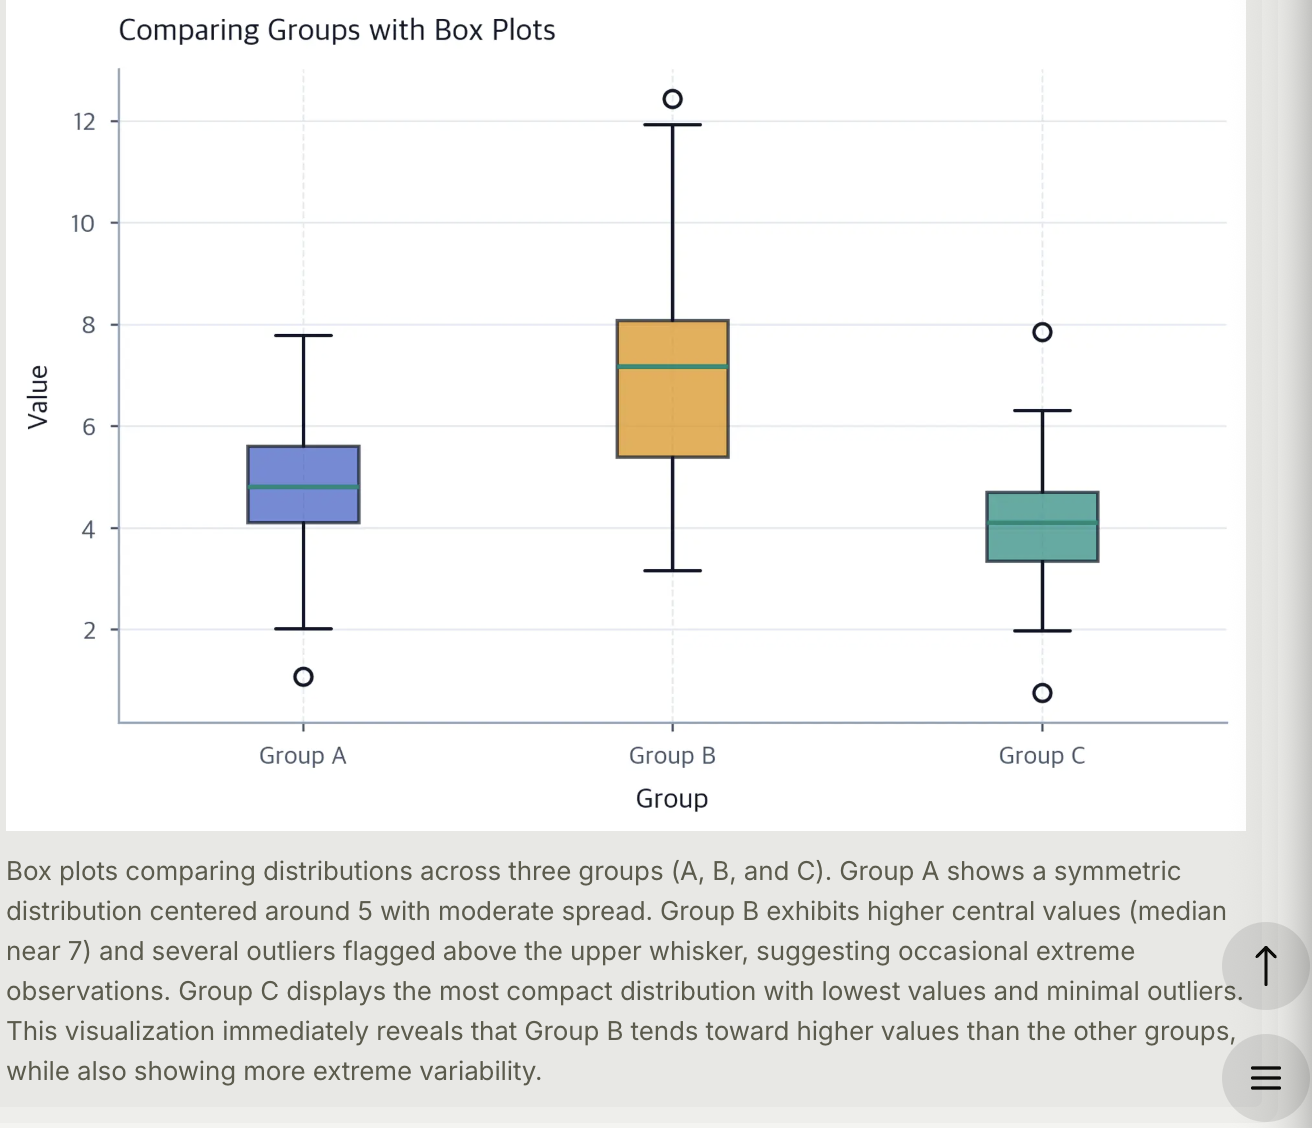


## 5. Scatter Plots: Revealing Relationships

Scatter plots display the relationship between two continuous variables by plotting each observation as a point in two-dimensional space. The resulting point cloud reveals patterns of association that summary statistics like correlation coefficients capture only partially. A tight linear arrangement of points indicates a strong relationship, while a diffuse cloud suggests weak or no association. Non-linear patterns (curves, clusters, or fan shapes) expose complexities that linear models would fail to capture.

The strength of scatter plots lies in their ability to reveal the nature of relationships, not just their existence. Two variables might have identical correlation coefficients but completely different scatter plot patterns. One might show a linear relationship, while another exhibits a curved relationship, and a third displays a linear trend distorted by a few influential outliers. Only the scatter plot distinguishes between these scenarios, guiding the choice of appropriate modeling techniques.

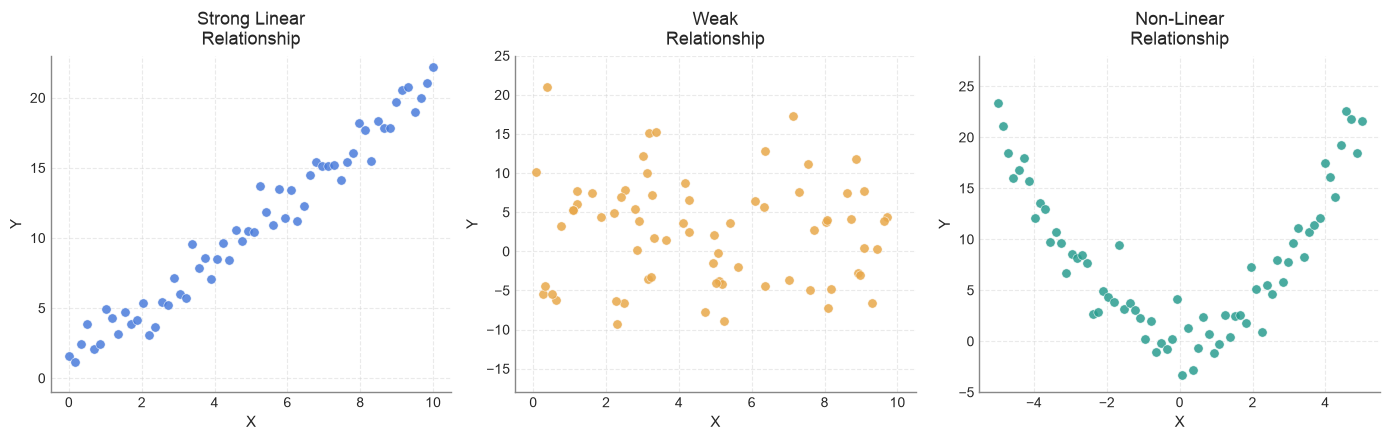

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# ---------- 1. Strong Linear Relationship ----------
x1 = np.linspace(0, 10, 60)
y1 = 2 * x1 + 1 + np.random.normal(0, 1.2, size=len(x1))   # tight linear + small noise

# ---------- 2. Weak Relationship ----------
x2 = np.random.uniform(0, 10, 70)
y2 = np.random.normal(2, 7, size=len(x2))                  # almost pure noise

# ---------- 3. Non-Linear (Quadratic) Relationship ----------
x3 = np.linspace(-5, 5, 70)
y3 = 0.9 * x3**2 + np.random.normal(0, 1.8, size=len(x3))  # clear parabola + noise

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Common styling
point_size = 45
alpha = 0.85

# ---- Left: Strong Linear ----
axes[0].scatter(x1, y1, c='#4A7CDB', s=point_size, alpha=alpha, edgecolors='white', linewidth=0.4)
axes[0].set_title('Strong Linear\nRelationship', fontsize=13, pad=8)
axes[0].set_xlabel('X', fontsize=11)
axes[0].set_ylabel('Y', fontsize=11)
axes[0].set_xlim(-0.5, 10.5)
axes[0].set_ylim(-1, 23)
axes[0].grid(True, linestyle='--', alpha=0.4)

# ---- Middle: Weak Relationship ----
axes[1].scatter(x2, y2, c='#E8A84A', s=point_size, alpha=alpha, edgecolors='white', linewidth=0.4)
axes[1].set_title('Weak\nRelationship', fontsize=13, pad=8)
axes[1].set_xlabel('X', fontsize=11)
axes[1].set_ylabel('Y', fontsize=11)
axes[1].set_xlim(-0.5, 10.5)
axes[1].set_ylim(-18, 25)
axes[1].grid(True, linestyle='--', alpha=0.4)

# ---- Right: Non-Linear Relationship ----
axes[2].scatter(x3, y3, c='#2A9D8F', s=point_size, alpha=alpha, edgecolors='white', linewidth=0.4)
axes[2].set_title('Non-Linear\nRelationship', fontsize=13, pad=8)
axes[2].set_xlabel('X', fontsize=11)
axes[2].set_ylabel('Y', fontsize=11)
axes[2].set_xlim(-5.5, 5.5)
axes[2].set_ylim(-5, 28)
axes[2].grid(True, linestyle='--', alpha=0.4)

# Clean up spines
for ax in axes:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#888888')
    ax.spines['bottom'].set_color('#888888')

plt.savefig("Plots/ScatterPlot.png", dpi=150)
plt.tight_layout()
plt.show()

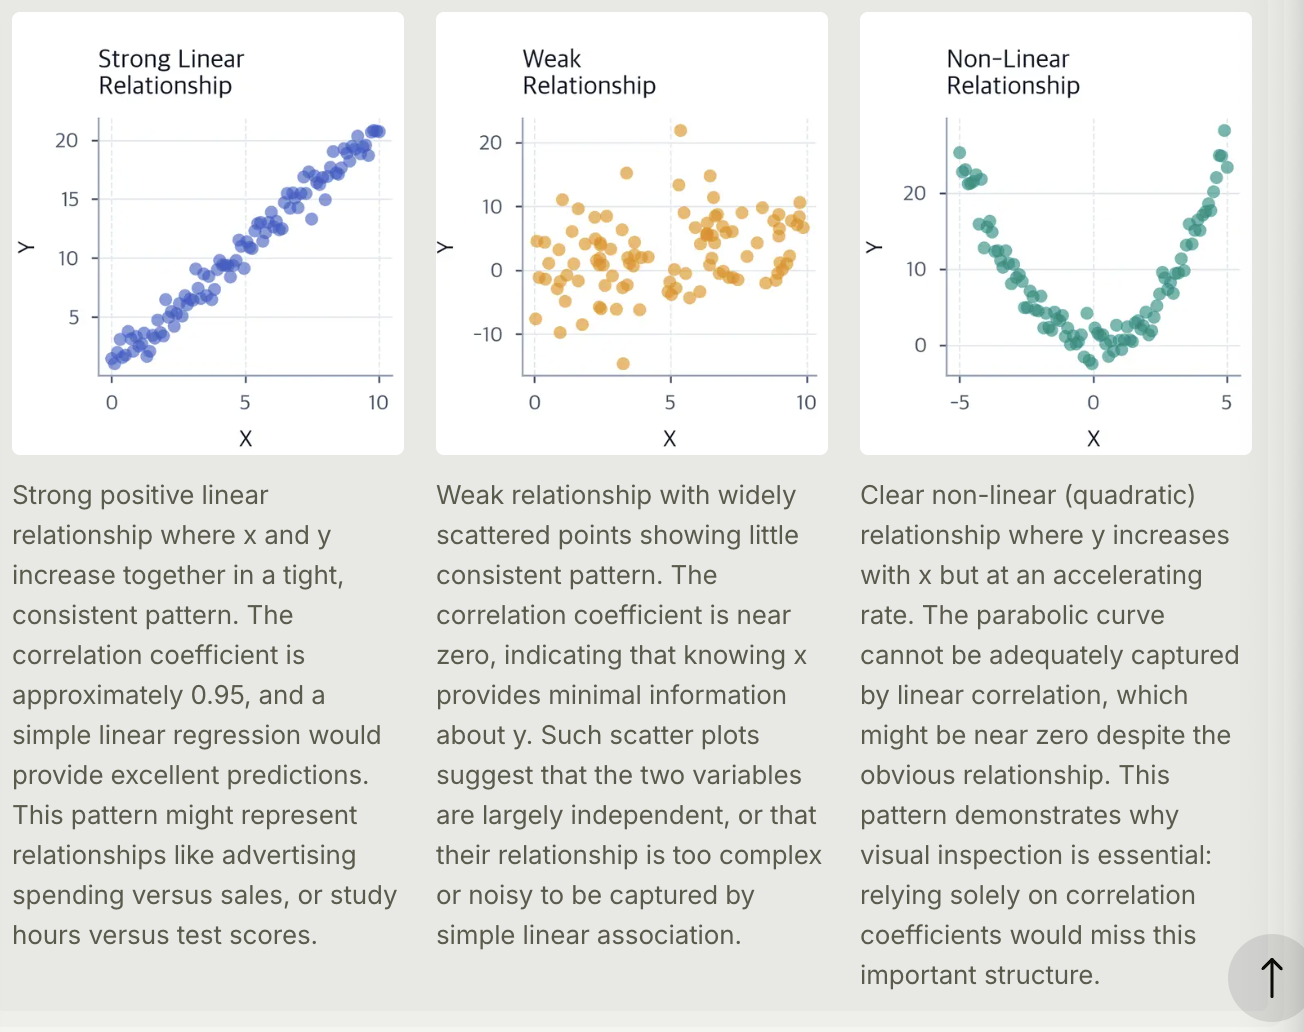

Scatter plots also expose violations of statistical assumptions that can undermine formal analyses. Heteroscedasticity, where the spread of points increases or decreases along the range of the predictor, violates an important assumption of ordinary least squares regression. A funnel-shaped scatter plot immediately reveals this problem, suggesting the need for robust regression methods or transformation of variables. Clusters of points separated by gaps might indicate distinct subgroups that should be modeled with categorical variables or mixture models rather than treating all observations as homogeneous.

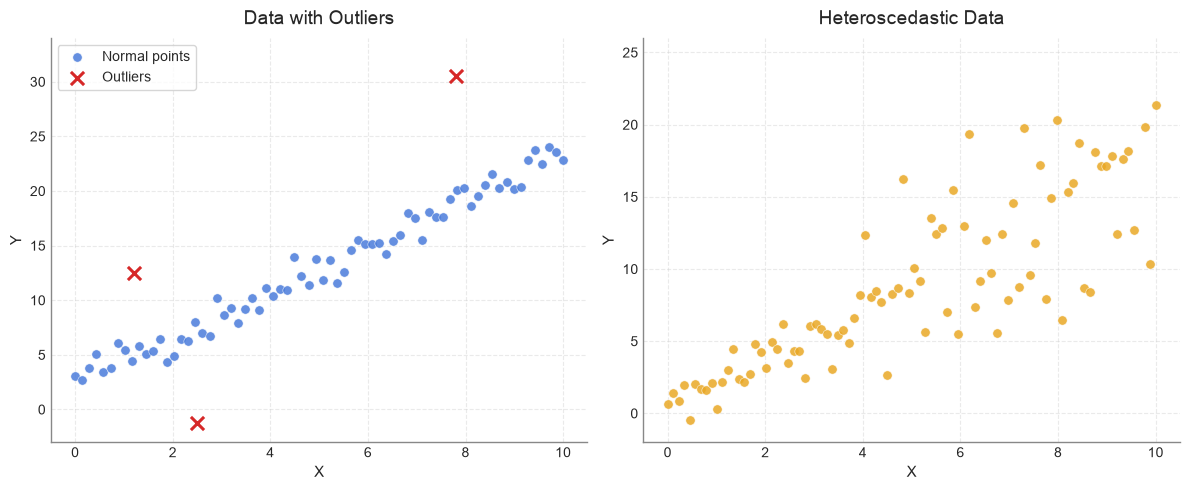

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# =====================================================
# 1. Data with Outliers
# =====================================================
x_normal = np.linspace(0, 10, 70)
y_normal = 2.1 * x_normal + 2.5 + np.random.normal(0, 1.1, size=len(x_normal))

# Clear outliers (will be plotted as red X)
outliers_x = np.array([1.2, 2.5, 7.8])
outliers_y = np.array([12.5, -1.2, 30.5])

# =====================================================
# 2. Heteroscedastic Data (funnel / increasing variance)
# =====================================================
x_hetero = np.linspace(0, 10, 90)
# Variance increases with x
noise = np.random.normal(0, 0.4 + 0.55 * x_hetero, size=len(x_hetero))
y_hetero = 1.7 * x_hetero + 0.5 + noise

# =====================================================
# Create the figure
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---------- Left plot: Data with Outliers ----------
ax1 = axes[0]
ax1.scatter(x_normal, y_normal, c='#4A7CDB', s=45, alpha=0.85,
            edgecolors='white', linewidth=0.4, label='Normal points')
ax1.scatter(outliers_x, outliers_y, c='#D62828', s=90, marker='x',
            linewidth=2.2, label='Outliers', zorder=5)

ax1.set_title('Data with Outliers', fontsize=14, pad=10)
ax1.set_xlabel('X', fontsize=11)
ax1.set_ylabel('Y', fontsize=11)
ax1.set_xlim(-0.5, 10.5)
ax1.set_ylim(-3, 34)
ax1.legend(loc='upper left', frameon=True, fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.4)

# ---------- Right plot: Heteroscedastic Data ----------
ax2 = axes[1]
ax2.scatter(x_hetero, y_hetero, c='#E9A825', s=45, alpha=0.85,
            edgecolors='white', linewidth=0.4)

ax2.set_title('Heteroscedastic Data', fontsize=14, pad=10)
ax2.set_xlabel('X', fontsize=11)
ax2.set_ylabel('Y', fontsize=11)
ax2.set_xlim(-0.5, 10.5)
ax2.set_ylim(-2, 26)
ax2.grid(True, linestyle='--', alpha=0.4)

# Clean spines
for ax in axes:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#888888')
    ax.spines['bottom'].set_color('#888888')

plt.savefig("Plots/ScatterPlot_2.png", dpi=150)
plt.tight_layout()
plt.show()

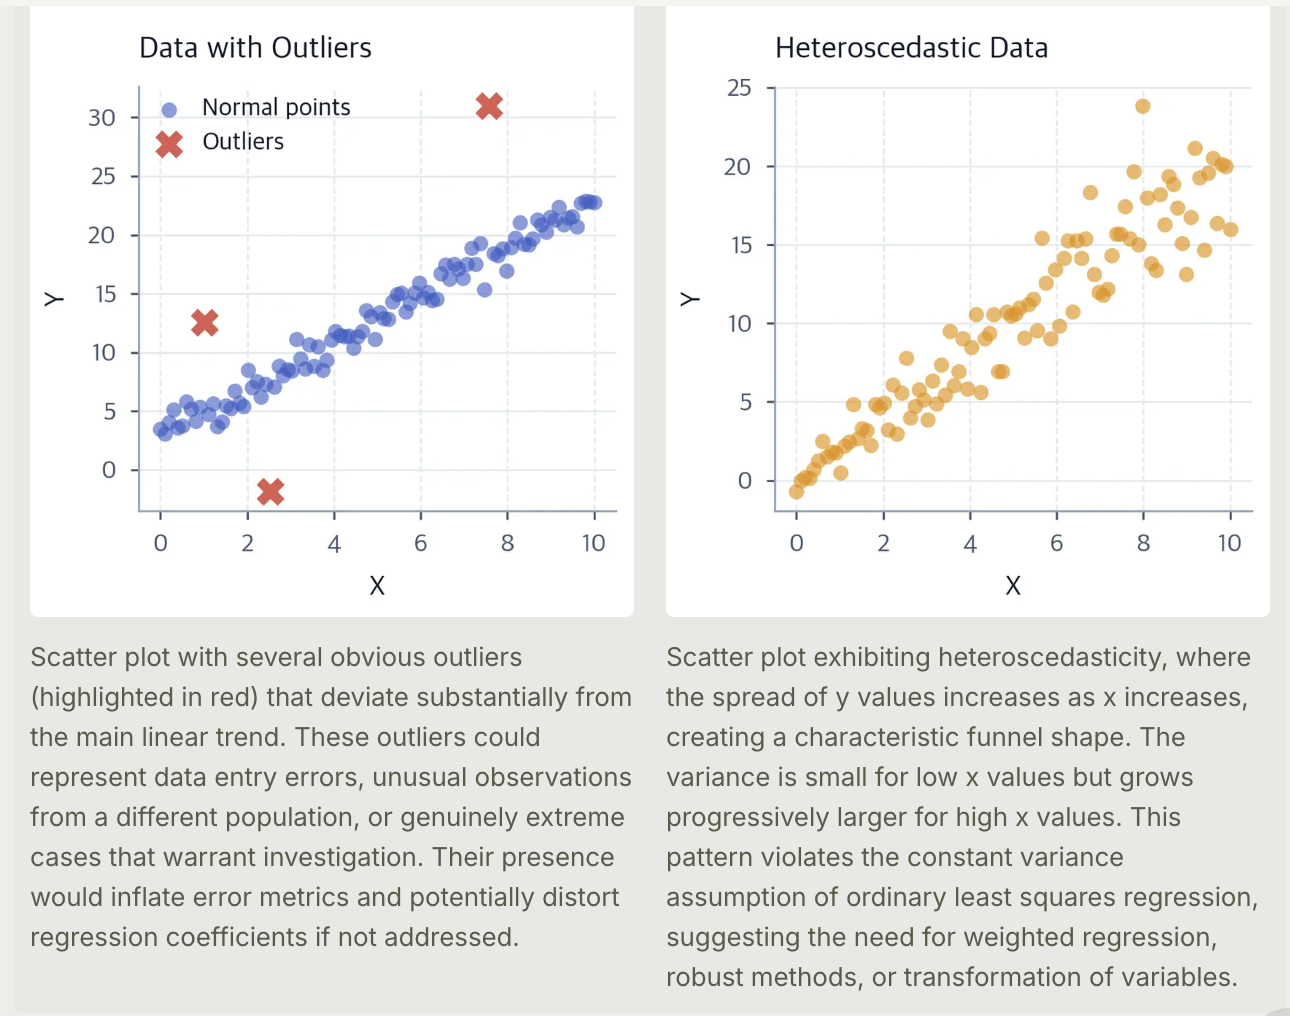

For datasets with many observations, overplotting can obscure patterns as thousands of points overlap and create solid blocks of color. Transparency settings (alpha blending) partially address this by allowing dense regions to appear darker while preserving visibility of individual points in sparse areas. Hexagonal binning or contour plots provide alternative representations that summarize point density when datasets grow too large for individual points to remain distinguishable.

## 6. Choosing the Right Visualizaiton

Selecting the appropriate visualization depends on the question being asked and the type of data available. Histograms work best for understanding the distribution of a single continuous variable, showing its overall shape as well as its center and spread. Box plots excel at comparing distributions across multiple groups, making differences in central tendency and variability immediately apparent. Scatter plots are particularly valuable for exploring relationships between two continuous variables, exposing patterns that correlation coefficients alone might miss.

In practice, effective exploratory data analysis employs multiple visualization types in combination. A histogram might reveal that a variable is skewed, prompting investigation of a log transformation. A box plot comparison across groups might expose outliers in certain categories, leading to targeted data quality checks. A scatter plot might suggest a non-linear relationship, informing the choice of modeling approach. Each visualization provides a different lens on the data, and together they build an understanding that pure computation cannot replace.

Modern data analysis workflows often begin with automated visualization dashboards that generate standard plots for all variables and relationships in a dataset. These automated tools provide efficient first-pass exploration, though they cannot replace the thoughtful, iterative visual investigation that experienced analysts perform when guided by domain knowledge and specific hypotheses. The point is to examine the plots critically, ask what patterns they reveal, and allow those patterns to guide subsequent analytical decisions.


## 7. Limitations

While visualization is valuable for data exploration, it has important limitations that practitioners should recognize. Visual interpretation is inherently subjective, and different viewers may draw different conclusions from the same plot. What one analyst sees as a meaningful pattern might appear to another as random noise. This subjectivity makes visualization most powerful when combined with formal statistical tests that quantify uncertainty and provide objective criteria for decision-making.

The choice of visual encoding (colors, scales, aspect ratios, and binning strategies) significantly influences interpretation. Poorly chosen scales can exaggerate trivial differences or obscure important patterns. Misleading axis ranges, truncated axes, or inappropriate transformations can create false impressions that lead to incorrect conclusions. Best practices for visualization design, such as starting axes at zero for bar charts and using consistent scales across comparison plots, help mitigate these risks but require conscious attention and discipline.

High-dimensional data presents particular challenges, as the human visual system is limited to perceiving two or three spatial dimensions directly. While techniques like small multiples, color encoding, and interactive visualizations extend our capacity to explore high-dimensional relationships, they cannot fully overcome the fundamental constraint that we cannot simultaneously visualize all pairwise relationships in datasets with dozens or hundreds of variables. Dimension reduction techniques like PCA or t-SNE provide alternative approaches for visualizing high-dimensional structure, but these come with their own interpretational complexities.

Finally, visualization works best for small to medium-sized datasets where individual observations remain distinguishable or where binning and aggregation preserve meaningful detail. Very large datasets (millions or billions of observations) may require sophisticated visualization techniques like density plots, aggregation to hexagonal bins, or statistical sampling to remain tractable. In such cases, the goal shifts from displaying all data to creating representative summaries that capture essential distributional features while remaining interpretable.

## 8. Practical Applications

Visualization serves important functions throughout the data science lifecycle, from initial exploration through final communication of results. During exploratory data analysis, visualizations guide data cleaning by exposing outliers, missing value patterns, and implausible observations that require investigation. A histogram might reveal that age values include impossible entries like 200 or -5, while a time series plot might expose sensor failures where values suddenly flatline.

In model building, visualizations inform feature engineering and model selection decisions. Scatter plots revealing non-linear relationships suggest polynomial terms or spline transformations. Distribution histograms showing severe skewness might motivate log transformations to achieve approximate normality. Box plots comparing predictor distributions across outcome categories help identify potentially informative features while flagging concerns about class imbalance that could bias model training.

Model diagnostic plots form an important validation step after fitting statistical models or machine learning algorithms. Residual plots (residuals versus fitted values) expose heteroscedasticity, non-linearity, and other violations of modeling assumptions. Quantile-quantile (Q-Q) plots compare residual distributions to theoretical normal distributions, validating assumptions required for inference. Calibration plots for classification models reveal whether predicted probabilities align with actual frequencies, indicating whether the model is well-calibrated or exhibits systematic bias.

Finally, visualization helps with communicating analytical results to diverse audiences. Decision-makers without statistical training can grasp patterns in well-designed plots that would be opaque in tables of coefficients or p-values. Effective visualization maps analytical insights into actionable understanding, bridging the gap between technical analysis and practical business impact. Skilled data scientists combine analytical expertise with effective communication, using visualization as a tool for both discovery and persuasion.


## Summary

Visualization gives intuitive understanding of data that precedes and informs all subsequent analysis. Histograms reveal distributional properties like shape, center, spread, and the presence of multiple modes or extreme skewness. Box plots concisely summarize key statistics while allowing efficient comparisons across groups and showing potential outliers. Scatter plots expose relationships between variables.

The practice of looking at data before computing statistics is not mere convention but important discipline. Visual patterns guide the selection of appropriate statistical methods, reveal violations of modeling assumptions, and expose data quality issues that could invalidate formal analyses. While visualization is inherently subjective and should be complemented by rigorous statistical testing, it remains a foundational step in transforming raw data into reliable insight. By developing strong visualization habits and cultivating visual intuition, practitioners build the basis for all subsequent analytical work.
